In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [2]:
import matplotlib.patches as patches


def add_largest_maze_walls(ax):    

    maze_optim = [
        (1, 1, 1, 2),    
        (0, 4, 2, 1),
        (3, 1, 1, 4),
        (5, 0, 1, 1),
        (4, 2, 3, 1),
        (1, 6, 3, 1),
        (4, 4, 2, 1),
        (5, 6, 2, 1),
        (1, 8, 1, 1),
        (3, 7, 1, 2),
        (5, 8, 1, 2)
    ]

    block_size = 0.025 * 80

    height, width = 7, 10
    torso_x, torso_y = (width - 1)*block_size, (height - 1)*block_size

    rects = []
    for i in range(len(maze_optim)):
        (y, x, w, h) = maze_optim[i]
            
        x = x * block_size * 2 - torso_x + (h - 1) * block_size - h * block_size + 18
        y = y * block_size * 2 - torso_y + (w - 1) * block_size - w * block_size + 12
        h, w = h * block_size * 2, w * block_size * 2
        w = w * 1.
        y = y * 1.
        rect = patches.Rectangle((x, y), h, w, linewidth=2, edgecolor='gray', facecolor='gray')

        ax.add_patch(rect)


In [3]:
TRAJECTORY_LEN = 1001
STATE_DIM = 29
# FEATURES_TO_CONSIDER = [0, 1, 15, 16]
FEATURES_TO_CONSIDER = torch.arange(29)

KEEP_ONLY_COORDS = False

TRAJECTORY_NUM_ANCHORS = 1000
Z_DIM = 128

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
env = gym.make('antmaze-large-diverse-v2')
dataset = env.get_dataset()

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28
/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Target Goal:  (32.89847138805485, 24.18034211496171)


load datafile: 100%|██████████| 8/8 [00:01<00:00,  5.42it/s]


In [5]:
dataset_trajectories = torch.tensor(dataset['observations'])
dataset_trajectories = dataset_trajectories[..., :STATE_DIM]
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions'])
dataset_terminals = torch.tensor(dataset['terminals'])
dataset_timeouts = torch.tensor(dataset['timeouts'])

dataset_goals = torch.tensor(dataset['infos/goal'])



# [:999*1001]

dataset_trajectories = dataset_trajectories[:999*1001].reshape(-1, 1001, STATE_DIM)
dataset_actions = dataset_actions[:999*1001].reshape(-1, 1001, 8)
dataset_terminals = dataset_terminals[:999*1001]
dataset_timeouts = dataset_timeouts[:999*1001].reshape(-1, 1001)

num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [6]:
dataset_mean = dataset_trajectories.mean([0, 1])
dataset_std = dataset_trajectories.std([0, 1])
dataset_std = torch.ones_like(dataset_std)

def normalize_dataset_coords(dataset_, features_to_consider_only=False):
    # return dataset_    
    is_numpy = isinstance(dataset_, np.ndarray)
    if is_numpy: dataset_ = torch.tensor(dataset_)
    
    dataset = dataset_.clone()
    if not features_to_consider_only:
        dataset = (dataset - dataset_mean.to(dataset.device)) / dataset_std.to(dataset.device)
    else:
        dataset = (dataset - dataset_mean[FEATURES_TO_CONSIDER]) / dataset_std[FEATURES_TO_CONSIDER]
    if is_numpy: dataset = np.array(dataset.cpu())
    return dataset

dataset_trajectories_cuda = dataset_trajectories.to(device)


# Trajectory encoder:

In [7]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a long enough PEs tensor
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # (1, max_len, d_model) so it can be broadcast over batch
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]  # match seq_len
        return self.dropout(x)


In [8]:
class TransformerEncoder(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=Z_DIM):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim)

        self.state_predict = nn.Sequential(
            nn.Linear(TRAJECTORY_NUM_ANCHORS + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, self.obs_len),
        )

        
        self.positional_encoding = PositionalEncoding(d_model=reward_pairs_emb_dim, dropout=0.1, max_len=TRAJECTORY_NUM_ANCHORS)



    def get_transformer_encoding(self, states, pad_mask):  
        
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=states.device)
        # pad_mask.shape = [batch, anchors]
                
        state_emb = self.state_embed(states)
                
        x = self.positional_encoding(state_emb)
        w_pre = self.encoder_transformer(x, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, states_index): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, states_index.shape[1], 1)        
        
        states_index = F.one_hot(states_index, num_classes=TRAJECTORY_NUM_ANCHORS)
        
        w_and_obs = torch.concatenate([z_expand, states_index], axis=-1)
        
        state_pred = self.state_predict(w_and_obs)
    
        return state_pred # [batch, reward_pairs]    

In [9]:
class TrajectoryEncoder:
    def __init__(self, obs_dim, fre_network: TransformerEncoder):
        self.obs_dim = obs_dim
        
        self.fre_network = fre_network.to(device)
        self.optimimizer = torch.optim.Adam(self.fre_network.parameters(), lr=0.001)

        self.len_params = Z_DIM
        
    
    
    def get_reward(self, obs, w):
        self.fre_network.eval()
        
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
    

    
    def get_training_data(self, batch_size, num_anchors, num_states):

        trajectory_idx_ = torch.randint(0, num_trajectories, size=(batch_size,))

        trajectory_idx = trajectory_idx_.unsqueeze(1).repeat(1, num_anchors)
        anchors_idx = torch.linspace(0, len_trajectory-1, num_anchors).long().unsqueeze(0).repeat(batch_size, 1)
        # anchors_idx = torch.randint(0, len_trajectory, (batch_size, num_anchors))
        anchors = dataset_trajectories[trajectory_idx, anchors_idx]

        trajectory_idx = trajectory_idx_.unsqueeze(1).repeat(1, num_states)
        states_idx = torch.randint(0, len_trajectory, (batch_size, num_states))
        states = dataset_trajectories[trajectory_idx, states_idx]

        return anchors, states

        
    def train_step_VAE(self, batch_size, num_anchors, num_states):
        self.fre_network.train()
        
        anchors, states = self.get_training_data(
            batch_size=batch_size, 
            num_anchors=num_anchors, 
            num_states=num_states,
        )
        anchors = anchors.to(device)
        
        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, pad_mask=None)
        
        
        # Calculate the loss:
        
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        
        rabdom_states_idx = torch.randint(0, TRAJECTORY_NUM_ANCHORS, (batch_size, 200,), device=device, dtype=torch.long)
        traj_indicies = torch.arange(0, batch_size).unsqueeze(1).repeat(1, 200)
        
        target_states = anchors[traj_indicies.flatten(), rabdom_states_idx.flatten()].reshape(batch_size, 200, -1)
        
        predicted_states = self.fre_network.get_reward_pred(w, rabdom_states_idx)
        
        # print(target_states.shape, predicted_states.shape)
        pred_loss = (target_states - predicted_states).pow(2).sum(-1).mean()



        kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
        loss = (pred_loss) + kl_loss * 0.01
        
        
        self.optimimizer.zero_grad()
        loss.backward()
        self.optimimizer.step()
        
        return {
            'loss': loss.item(),
            'pred_loss': pred_loss.item(),
            'kl_loss': kl_loss.item(),
            'target_states': target_states.cpu(),
            'predicted_states': predicted_states.detach().cpu(),
        }
        
        

    
    
    def get_z_from_random_anchors(self, batch_size: int, num_anchors:int):
        # assert self.new_states_buffer is not None
        self.fre_network.eval()
        
        (anchors, next_states, pad_mask), (all_states, state_in_trajectory), info = self.get_training_data(
            batch_size=batch_size, 
            num_anchors=num_anchors, 
            num_states=num_anchors+1,
        )
        anchors = anchors.to(device)
        next_states = next_states.to(device)
        pad_mask = pad_mask.to(device)

        eval_z, _ = self.get_z_from_anchors(anchors, pad_mask)
        
        return eval_z, {'anchors': anchors.cpu(), 'pad_mask': pad_mask.cpu(), 'next_states': next_states.cpu(), 'get_training_data:info': info}
        
            
    def get_z_from_anchors(self, anchors: torch.Tensor, pad_mask: torch.Tensor):    
        assert anchors.shape[:-1] == pad_mask.shape
        self.fre_network.eval()
        
        batch_size = anchors.shape[0]
        
        with torch.no_grad():
            w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, pad_mask) 
        
        # eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        # z = w_mean + eps * torch.exp(w_log_std)
        z = w_mean
        
        return z, {'anchors': anchors.cpu()}
    
    
    

In [10]:
fre_network = TransformerEncoder(obs_len=obs_dim)
fre_network.load_state_dict(torch.load('models/offline_BC+iql-fre_network.pth'))

trajectory_encoder = TrajectoryEncoder(
    obs_dim=2,
    fre_network=fre_network,
)

vae_loss, vae_kl_loss = [], []

/tmp/ipykernel_4169/176225724.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fre_network.load_state_dict(torch.load('models/offline_BC+iql-fre_network.pth'))


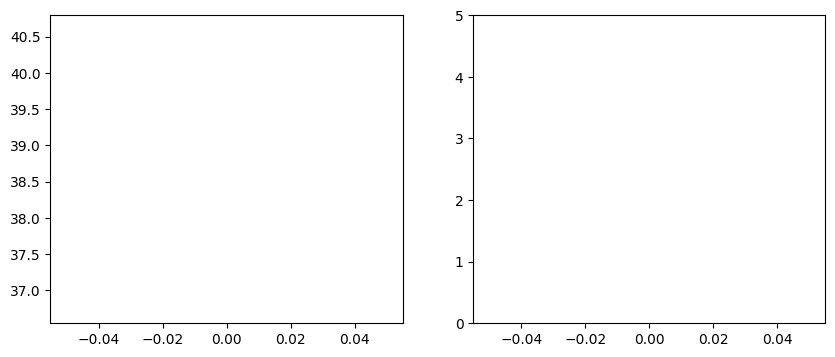

In [11]:
for i in tqdm(range(5000), desc='VAE training', leave=False):
    # break
    vae_loss_dict = trajectory_encoder.train_step_VAE(
        batch_size=64,
        num_anchors=TRAJECTORY_NUM_ANCHORS,
        num_states=800,
    )
    vae_loss.append(vae_loss_dict['loss'])
    vae_kl_loss.append(vae_loss_dict['kl_loss'])
    
    
    
    if i % 10 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(vae_loss)
        # axs[0].set_ylim([0, 2])
        axs[1].plot(vae_kl_loss)    
        axs[1].set_ylim([0, 5])
        
        plt.show()
        
    break

In [12]:
# torch.save(fre_network.state_dict(), 'models/offline_BC+iql-fre_network.pth')

In [13]:
# b = 0

# fig, ax = plt.subplots(1, 1)
# ax.scatter(vae_loss_dict['target_states'][b, :, 0], vae_loss_dict['target_states'][b, :, 1])
# ax.scatter(vae_loss_dict['predicted_states'][b, :, 0], vae_loss_dict['predicted_states'][b, :, 1])
# add_largest_maze_walls(ax)

# IQL model:

In [14]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    """Generic MLP with Mish activation and LayerNorm."""
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        prev_dim = input_dim

        # Add hidden layers with Mish activation and LayerNorm
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.Mish())
            # layers.append(nn.LayerNorm(hidden_dim))
            prev_dim = hidden_dim  # Update input size for next layer
        
        # Final output layer
        layers.append(nn.Linear(prev_dim, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class ValueCritic(nn.Module):
    def __init__(self, obs_dim, hidden_dims):
        super().__init__()
        self.model = MLP(obs_dim, hidden_dims, output_dim=1)

    def forward(self, x):
        return self.model(x)


class Critic(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_dims):
        super().__init__()

        self.model1 = MLP(obs_dim + action_dim, hidden_dims, output_dim=1)
        self.model2 = MLP(obs_dim + action_dim, hidden_dims, output_dim=1)

    def forward(self, x, action):
        x = torch.cat((x, action), dim=-1)
        
        q1 = self.model1(x)
        q2 = self.model2(x)
        
        return q1, q2



class Actor(nn.Module):
    def __init__(self, input_dim, action_dim, hidden_dims, init_std=0.0):
        super().__init__()
        self.model = MLP(input_dim, hidden_dims, output_dim=action_dim)  # MLP only predicts mean
        
        # Learnable log standard deviation (initialized to `init_std`)
        self.log_std = nn.Parameter(torch.ones(action_dim) * init_std)

    def forward(self, x, temperature=1.0):
        mean = self.model(x)  # Predict action mean

        log_std = torch.clip(self.log_std, -20, 2)
        mean = torch.clip(mean, -5, 5)

        return torch.distributions.Normal(
            mean, 
            torch.exp(log_std)*temperature
        )


from torch.optim.lr_scheduler import CosineAnnealingLR
import copy


class IQL(nn.Module):
    def __init__(self, state_dim, action_dim, w_dim=128):
        super(IQL, self).__init__()
        self.obs_len = state_dim
                
        self.critic = Critic(w_dim + state_dim, action_dim, hidden_dims=[256, 256])
        self.target_critic = copy.deepcopy(self.critic)
        for param in self.target_critic.parameters():
            param.requires_grad = False
        
        self.value = ValueCritic(w_dim + state_dim, hidden_dims=[256, 256])        
        self.actor = Actor(w_dim + state_dim, action_dim, hidden_dims=[256, 256])
        
        self.critic_optim = torch.optim.Adam(self.critic.parameters(), lr=0.003)
        self.value_optim = torch.optim.Adam(self.value.parameters(), lr=0.003)
        self.actor_optim = torch.optim.Adam(self.actor.parameters(), lr=0.003)
        self.actor_lr_schedule = CosineAnnealingLR(self.actor_optim, 100000)
        
        
    def get_value(self, w, obs):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.value(w_and_obs)

    def get_critic(self, w, obs, actions):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.critic(w_and_obs, actions)
    
    def get_target_critic(self, w, obs, actions):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.target_critic(w_and_obs, actions)

    def get_actor(self, w, obs, temperature=1.0):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.actor(w_and_obs, temperature)
    
    
    
# def update_target_critic(critic, target_critic, tau):

#     critic_state_dict = critic.state_dict()
#     target_critic_state_dict = target_critic.state_dict()

#     for key in critic_state_dict:
#         target_critic_state_dict[key] = tau * critic_state_dict[key] + (1 - tau) * target_critic_state_dict[key]

#     target_critic.load_state_dict(target_critic_state_dict)
    
    
def update_target_critic(source, target, alpha):
    for target_param, source_param in zip(target.parameters(), source.parameters()):
        target_param.data.mul_(1. - alpha).add_(source_param.data, alpha=alpha)
    
    
def expectile_loss(u, expectile=0.7):
    weight = torch.where(
        u.detach() >= 0, 
        torch.tensor(expectile, dtype=u.dtype), 
        torch.tensor(1 - expectile, dtype=u.dtype)
    )
    return weight * (u ** 2)


def smooth_and_downsample(losses, smoothing=0.9, max_points=100):
    if not losses: return []
    smoothed = [losses[0]]
    for loss in losses[1:]:
        smoothed.append(smoothing * smoothed[-1] + (1 - smoothing) * loss)
    downsample = max(1, len(smoothed) // max_points)  # Ensure at least 1
    return smoothed[::downsample]

In [438]:
def get_training_data(batch_size, num_states, in_target_states_ratio, num_anchors=TRAJECTORY_NUM_ANCHORS):
    # batch_size = 16
    # num_states = 2048
    # in_target_states_ratio = 0.5

    target_trajectory_idx_ = torch.randint(0, num_trajectories, (batch_size,))
    # target_trajectory_idx_ = torch.full_like(target_trajectory_idx_, fill_value=2)


    num_target_states = int(num_states * in_target_states_ratio)
    num_random_states = num_states - num_target_states


    target_trajectory_idx = target_trajectory_idx_.unsqueeze(1).repeat(1, num_target_states).reshape(-1)
    target_states_idx = torch.randint(0, len_trajectory-1, (num_target_states*batch_size,))

    rewards_values = torch.linspace(0.2, 2, len_trajectory)
    rewards_values[100:] = 0
    
    target_states = dataset_trajectories[target_trajectory_idx, target_states_idx].reshape(batch_size, num_target_states, -1)
    target_next_states = dataset_trajectories[target_trajectory_idx, target_states_idx + 1].reshape(batch_size, num_target_states, -1)
    target_actions = dataset_actions[target_trajectory_idx, target_states_idx].reshape(batch_size, num_target_states, -1)
    # target_rewards = torch.full((batch_size, num_target_states), fill_value=1, dtype=torch.float)
    target_rewards = rewards_values[target_states_idx.reshape(batch_size, num_target_states)]
    target_masks = ~dataset_timeouts[target_trajectory_idx, target_states_idx + 1].reshape(batch_size, num_target_states)
    # target_values = values[target_states_idx.reshape(batch_size, num_target_states)]


    random_trajectory_idx = torch.randint(0, num_trajectories, (num_random_states*batch_size,))
    random_states_idx = torch.randint(0, len_trajectory-1, (num_random_states*batch_size,))

    random_states = dataset_trajectories[random_trajectory_idx, random_states_idx].reshape(batch_size, num_random_states, -1)
    random_next_states = dataset_trajectories[random_trajectory_idx, random_states_idx + 1].reshape(batch_size, num_random_states, -1)
    random_actions = dataset_actions[random_trajectory_idx, random_states_idx].reshape(batch_size, num_random_states, -1)
    random_rewards = torch.full((batch_size, num_random_states), fill_value=0, dtype=torch.float)
    random_masks = ~dataset_timeouts[random_trajectory_idx, random_states_idx + 1].reshape(batch_size, num_random_states)
    # random_values = torch.full((batch_size, num_random_states), fill_value=-1, dtype=torch.float32)


    states = torch.concat((target_states, random_states), dim=1)
    next_states = torch.concat((target_next_states, random_next_states), dim=1)
    actions = torch.concat((target_actions, random_actions), dim=1)
    rewards = torch.concat((target_rewards, random_rewards), dim=1).unsqueeze(-1)
    masks = torch.concat((target_masks, random_masks), dim=1).unsqueeze(-1)
    # values = torch.concat((target_values, random_values), dim=1).unsqueeze(-1)
    
    
    trajectory_idx = target_trajectory_idx_.unsqueeze(1).repeat(1, num_anchors)
    anchors_idx = torch.linspace(0, len_trajectory-1, num_anchors).long().unsqueeze(0).repeat(batch_size, 1)
    anchors = dataset_trajectories[trajectory_idx, anchors_idx]


    return {
        'states': states.to(device),
        'next_states': next_states.to(device), 
        'actions': actions.to(device),
        'rewards': rewards.to(device),
        # 'values': values.to(device),
        'masks': masks.to(device),
        'anchors': anchors.to(device),
    }
    

# batch = get_training_data(batch_size=16, num_states=2048, in_target_states_ratio=0.5)

# fig, ax = plt.subplots(1, 1)
# b = 0
# plt.scatter(batch['states'][b, :, 0], batch['states'][b, :, 1], c=batch['rewards'][b])
# add_largest_maze_walls(ax)

In [439]:
iql_agent = IQL(state_dim=obs_dim, action_dim=8).to(device)
# iql_agent.load_state_dict(torch.load('offline_BC+iql-iql_agent.pth'))


actor_losses = []
v_losses, q_losses = [], []
mse_errors = []
stds = []

In [440]:
# torch.save(iql_agent.state_dict(), 'offline_BC+iql-iql_agent-test.pth')

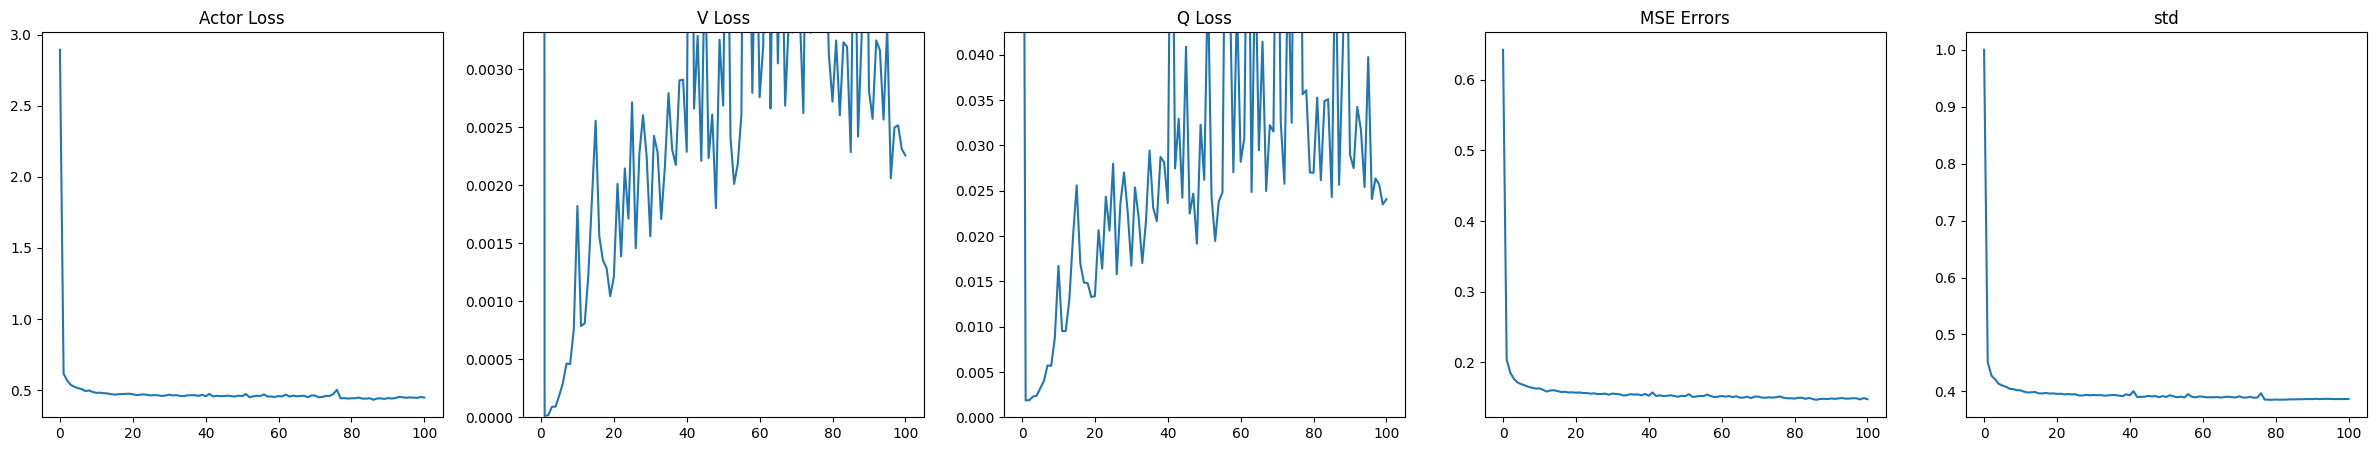

100%|██████████| 100000/100000 [59:52<00:00, 27.83it/s]


In [442]:
config = {
    'expectile': 0.8,
    'temperature': 3.0,
    'discount': 0.99,
    'tau': 0.005,
}

iql_batch_size = 64
iql_num_states = 2048



for timestep in tqdm(range(100_000)):

    
    batch = get_training_data(batch_size=16, num_states=1024, in_target_states_ratio=0.2)
    
    # break
    
    
    with torch.no_grad():
        w_mean, _ = fre_network.get_transformer_encoding(batch['anchors'], pad_mask=None)

    # break

    # Implicit Q-Learning
    w_target = w_mean.unsqueeze(1).repeat(1, batch['states'].shape[1], 1)
    
    with torch.no_grad():
        
        target_q1, target_q2 = iql_agent.get_target_critic(w_target, batch['states'], batch['actions'])
        target_q1, target_q2 = target_q1.detach(), target_q2.detach()
        target_q = torch.minimum(target_q1, target_q2)
        next_v = iql_agent.get_value(w_target, batch['next_states']).detach()
    
    
    # Value Loss: Update V towards expectile of min(q1, q2).
    
    v = iql_agent.get_value(w_target, batch['states'])
    v_loss_Q = expectile_loss(target_q - v, config['expectile'])
    # v_loss_G = expectile_loss(batch['values'] - v, config['expectile'])

    # v_loss = (batch['values'] != -1) * v_loss_G + (batch['values'] == -1) * v_loss_Q
    v_loss = v_loss_Q
    
    v_loss = v_loss.mean()

    iql_agent.value.zero_grad(set_to_none=True)
    v_loss.backward()
    iql_agent.value_optim.step()

    # Critic Loss. Update Q = r #############################
    
    targets = batch['rewards'] + config['discount'] * batch['masks'] * next_v
    # targets = -0.1 + config['discount'] * batch['masks'] * next_v
    

    q1, q2 = iql_agent.get_critic(w_target, batch['states'], batch['actions'])
    q_loss = ((q1 - targets).pow(2).mean() + (q2 - targets).pow(2).mean()) / 2
    q_loss = q_loss
    
    iql_agent.critic.zero_grad(set_to_none=True)
    q_loss.backward()
    iql_agent.critic_optim.step()


    update_target_critic(iql_agent.critic, iql_agent.target_critic, config['tau'])


    value_info = {
        'v_loss': v_loss,
        'q_loss': q_loss,
        'v': v.mean(),
        'q': torch.minimum(q1, q2).mean(),
    }
    
    # Actor Loss ############################################

    adv = (target_q - v).detach()
    actions = batch['actions']
    exp_a = torch.exp(adv.detach() * config['temperature']).clamp(max=100)
    
    dist = iql_agent.get_actor(w_target, batch['states'])
    log_probs = dist.log_prob(actions)
    actor_loss = -(exp_a * log_probs).mean()
    
    iql_agent.actor.zero_grad(set_to_none=True)
    actor_loss.backward()
    iql_agent.actor_optim.step()
    iql_agent.actor_lr_schedule.step()
    
    
    std = dist.stddev.mean()
    mse_error = ((dist.loc - batch['actions'])**2).mean()
    
    actor_info = {
        'actor_loss': actor_loss,
        'std': std,
        'adv': adv.mean(),
        'mse_error': mse_error,
    }

    ########################################################################################
    
    
    actor_losses.append(actor_loss.item())
    mse_errors.append(mse_error.item())
    stds.append(std.item())


    ########################################################################################
    
    
    
    v_losses.append(v_loss.item())
    q_losses.append(q_loss.item())
    
    if timestep % 200 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 5, figsize=(30, 5))
        
        axs[0].plot(smooth_and_downsample(actor_losses))
        # axs[0].set_ylim(0,max(actor_losses[-100:]))
        axs[0].set_title("Actor Loss")
        
        axs[1].plot(smooth_and_downsample(v_losses))
        axs[1].set_ylim(0,max(v_losses[-100:]))
        axs[1].set_title("V Loss")
        
        axs[2].plot(smooth_and_downsample(q_losses))
        axs[2].set_ylim(0,max(q_losses[-100:]))
        axs[2].set_title("Q Loss")
        
        axs[3].plot(smooth_and_downsample(mse_errors))
        # axs[3].set_ylim(0,max(mse_errors[-100:]))
        axs[3].set_title("MSE Errors")
        
        axs[4].plot(smooth_and_downsample(stds))
        axs[4].set_title("std")

        plt.show()
        
    # break

Target Goal:  (32.38166207289269, 24.994030072412574)


  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:01<00:00, 1267.08it/s]


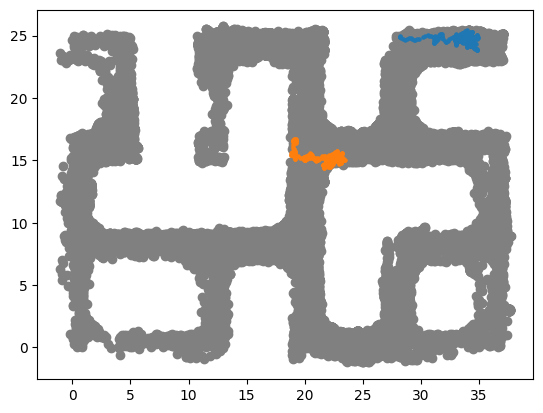

In [448]:
batch = get_training_data(batch_size=1, num_states=5000, in_target_states_ratio=0.2)


def reset_to_location(env, location):
    env.sim.reset()
    qpos = env.init_qpos + env.np_random.uniform(low=-.1, high=.1, size=env.model.nq)
    qpos[:2] = np.array(location).astype(env.observation_space.dtype)
    qvel = env.init_qvel + env.np_random.randn(env.model.nv) * .1
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()


env.reset()
location = (20, 15)
start_state = reset_to_location(env, location)
# start_state = normalize_dataset_coords(start_state)[..., :]
state = start_state

tensor_state = torch.tensor(state).reshape(1, -1).to(device).float() 



with torch.no_grad():
    w_mean, _ = trajectory_encoder.fre_network.get_transformer_encoding(batch['anchors'], pad_mask=None)
    w_mean = w_mean.unsqueeze(0)




produced_trajectory = []

for _ in tqdm(range(2000)):
    tensor_state = torch.tensor(state).reshape(1, 1, -1).to(device).float()
    
    with torch.no_grad():
        dist = iql_agent.get_actor(w_mean, tensor_state)
        pred_action = dist.loc.cpu()
        action = pred_action[0, 0]
        action = np.array(action)
        
    new_state, _, _, _ = env.step(action)

    
    produced_trajectory.append(state)

    state = new_state
    # state = normalize_dataset_coords(state)[..., :STATE_DIM]
    
    
produced_trajectory = np.stack(produced_trajectory)



plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')


# x = dataset_trajectories[trajectory_idx]
# print(x.any())
# plt.scatter(x[:, 0], x[:, 1])
# plt.scatter(anchors[0, ::5, 0].cpu(), anchors[0, ::5, 1].cpu(), c='red')
plt.scatter(batch['anchors'][..., 0].cpu(), batch['anchors'][..., 1].cpu(), s=5)    
plt.scatter(produced_trajectory[:, 0], produced_trajectory[:, 1], s=5)

In [444]:
with torch.no_grad():
    w_target = w_mean.repeat(1, batch['states'].shape[1], 1)    
    values = iql_agent.get_value(w_target, batch['states']).detach()

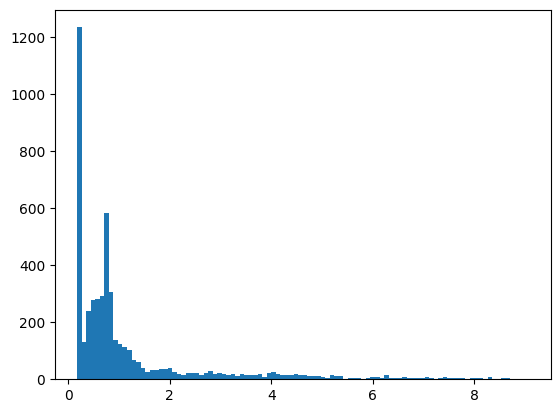

In [445]:
_ = plt.hist(values.cpu().flatten(), bins=100)

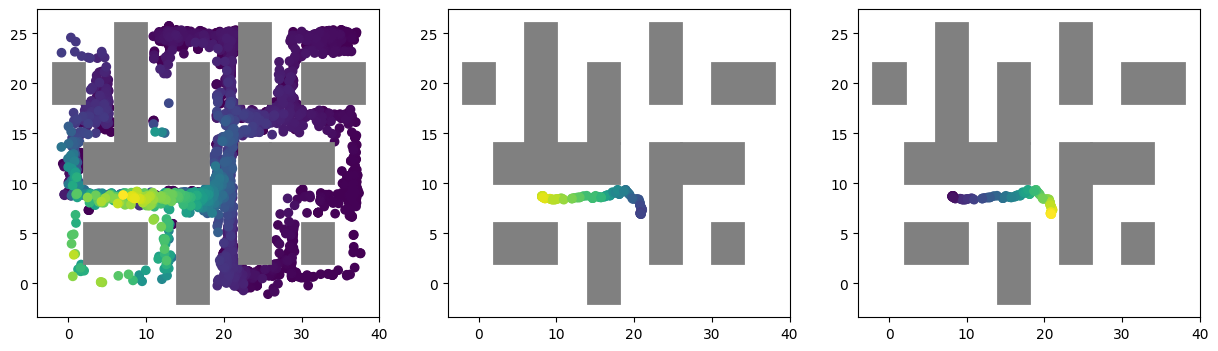

In [446]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

x = batch['states'][0, :, 0].cpu().flatten()
y = batch['states'][0, :, 1].cpu().flatten()
c = values[0].cpu().flatten()

sort_idx = np.argsort(c)
x = x[sort_idx]
y = y[sort_idx]
c = c[sort_idx]

    
# axs[0].scatter(batch['states'][0, :, 0].cpu(), batch['states'][0, :, 1].cpu(), c=values[0].cpu(), vmin=values.min().item(), vmax=values.max().item(), cmap='hot')
axs[0].scatter(x, y, c=c, vmin=values.min().item(), vmax=values.max().item())
add_largest_maze_walls(axs[0])

cond = (batch['rewards'][0, :, 0] != 0).bool()
axs[1].scatter(batch['states'][0][cond][:, 0].cpu(), batch['states'][0][cond][:, 1].cpu(), c=values[0][cond].cpu(), vmin=values.min().item(), vmax=values.max().item())
add_largest_maze_walls(axs[1])

cond = (batch['rewards'][0, :, 0] != 0).bool()
axs[2].scatter(batch['states'][0][cond][:, 0].cpu(), batch['states'][0][cond][:, 1].cpu(), c=batch['rewards'][0][cond].cpu())
add_largest_maze_walls(axs[2])

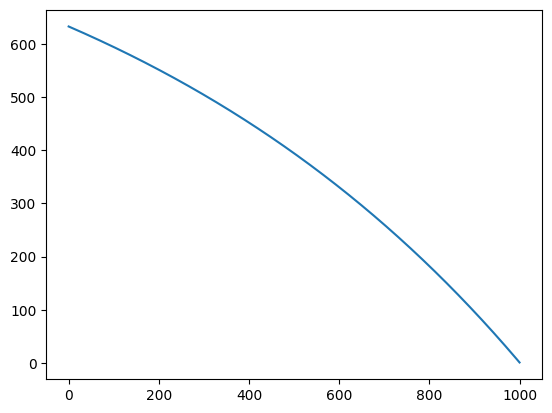

In [447]:
g = torch.zeros((1001,))
# g = torch.zeros((1001,))

g[1000] = 1
for i in range(999, -1, -1):
    g[i] = 1 + 0.999*g[i+1]
g

plt.plot(g)